# **Importing the Libraries**

In [65]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# **Importing the Dataset**

In [66]:
dataset = pd.read_excel('Customer_Segmentation.xlsx')
dataset['InvoiceDate'] = pd.to_datetime(dataset['InvoiceDate'])

# **Data Preprocessing**

**Converting all Values to String for Uniformity**

In [67]:
dataset['StockCode'] = dataset['StockCode'].astype(str)
dataset['Description'] = dataset['Description'].astype(str)
dataset['Country'] = dataset['Country'].astype(str)

**Converting Date-Time**

In [68]:
dataset['InvoiceDate'] = pd.to_datetime(dataset['InvoiceDate'])

**Creating Useful Metrics Feature**

In [69]:
dataset['TotalPrice'] = dataset['Quantity'] * dataset['UnitPrice']

**Aggregating Customer Transaction Data**

In [70]:
customer_data = dataset.groupby('CustomerID').agg({
    'TotalPrice': 'sum',
    'InvoiceNo': 'count',
    'Quantity': 'sum'
}).reset_index()

In [71]:
customer_data.columns = ['CustomerID', 'Monetary', 'Frequency', 'Quantity']

In [72]:
X = customer_data[['Monetary', 'Frequency', 'Quantity']].values

**Feature Scaling**

In [26]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X = sc.fit_transform(X)


# **Applying PCA**

In [74]:
from sklearn.decomposition import PCA
pca = PCA(n_components = 2)
X_pca = pca.fit_transform(X)

**Visualizing PCA Results**

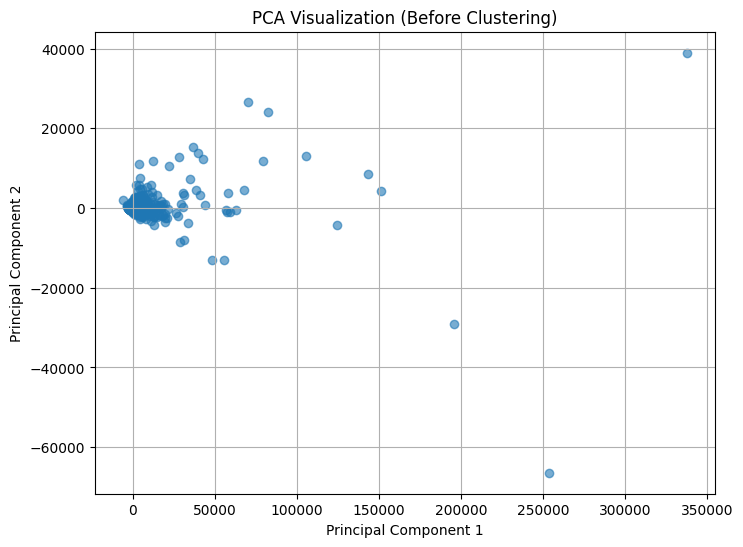

In [76]:
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.6)
plt.title('PCA Visualization (Before Clustering)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

**Cheaking Data Retension after PCA (97%)**

In [77]:
print(pca.explained_variance_ratio_)

[0.97092706 0.02859949]


# **Customer Segmentation via KMeans Clustering**

In [84]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters = 5, init = 'k-means++', random_state = 42)
y_kmeans = kmeans.fit_predict(X)

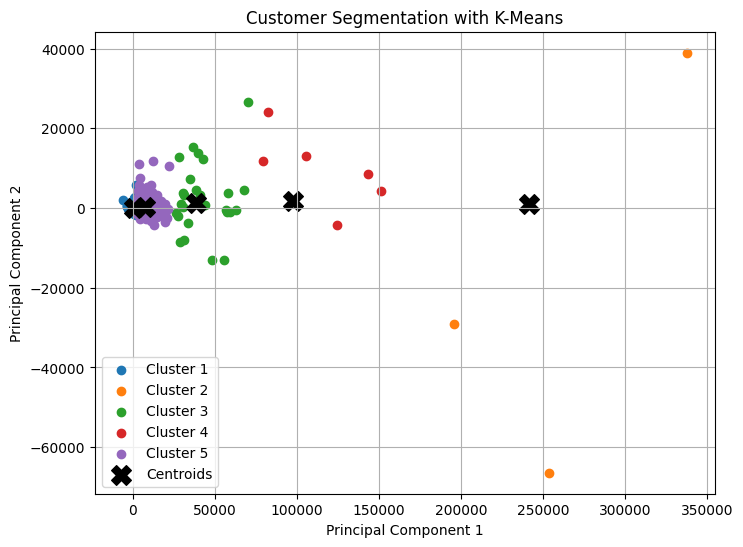

In [85]:
plt.figure(figsize=(8,6))
for cluster in range(kmeans.n_clusters):
    plt.scatter(
        X_pca[y_kmeans == cluster, 0],
        X_pca[y_kmeans == cluster, 1],
        label=f'Cluster {cluster+1}')

plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    s=200, c='black', marker='X', label='Centroids')

plt.title('Customer Segmentation with K-Means')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.show()



# **Customer Segmentation Results**

**Number and Size of Clusters**

In [86]:
import pandas as pd
cluster_counts = pd.Series(y_kmeans).value_counts()
print(cluster_counts)

sorted_clusters = cluster_counts.index.tolist()
label_mapping = {old_label: new_label+1 for new_label, old_label in enumerate(sorted_clusters)}
print(label_mapping)
y_kmeans_ordered = pd.Series(y_kmeans).map(label_mapping)
pd.Series(y_kmeans_ordered).value_counts()

0    4026
4     311
2      26
3       6
1       3
Name: count, dtype: int64
{0: 1, 4: 2, 2: 3, 3: 4, 1: 5}


,count
1,4026
2,311
3,26
4,6
5,3


**Customer Segment Metrics**

In [87]:
customer_data = dataset.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (dataset['InvoiceDate'].max() - x.max()).days,
    'InvoiceNo': 'count',
    'TotalPrice': 'sum',
    'Quantity': 'sum'
}).reset_index()

customer_data.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary', 'Quantity']

In [88]:
customer_data['Cluster'] = y_kmeans_ordered.values

In [89]:
cluster_summary = customer_data.groupby('Cluster').agg({
    'Recency': ['mean', 'min', 'max'],
    'Frequency': ['mean', 'min', 'max'],
    'Monetary': ['mean', 'min', 'max'],
    'Quantity': ['mean', 'min', 'max'],
    'CustomerID': 'count' })

cluster_summary.columns = ['_'.join(col).strip() for col in cluster_summary.columns.values]
cluster_summary = cluster_summary.reset_index()
print(cluster_summary)

   Cluster  Recency_mean  Recency_min  Recency_max  Frequency_mean  \
0        1     97.071287            0          373       65.342275   
1        2     22.643087            0          301      324.778135   
2        3      6.115385            0           38     1147.807692   
3        4      6.666667            0           23     1673.833333   
4        5      2.666667            0            7      956.333333   

   Frequency_min  Frequency_max  Monetary_mean  Monetary_min  Monetary_max  \
0              1            981     913.628128      -4287.63       4863.88   
1              1           2782    7444.475273          0.00      21535.90   
2             45           7983   38338.642692      20272.43      59419.34   
3            281           5903   97725.461667      62653.10     132572.62   
4            351           2085  241136.560000     187482.17     279489.02   

   Quantity_mean  Quantity_min  Quantity_max  CustomerID_count  
0     548.085941          -303          7026 

**Segment Value**

In [56]:
def label_cluster(row):
    if row['Monetary_mean'] > 1000:
        return 'High Value'
    elif row['Monetary_mean'] > 100:
        return 'Medium Value'
    else:
        return 'Low Value'

cluster_summary['ValueSegment'] = cluster_summary.apply(label_cluster, axis=1)
print(cluster_summary[['Cluster', 'CustomerID_count', 'ValueSegment']])

   Cluster  CustomerID_count  ValueSegment
0        1              3945  Medium Value
1        2               401    High Value
2        3                18    High Value
3        4                 4    High Value
4        5                 4    High Value
